<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Introduction to Simple Linear Regression - Solution

---

### About
An introduction to Linear Regression: what it is, how it works, and how to run a model using `scikit-learn`.

### Learning Objectives
- Describe modeling.
- Calculate mean squared error.
- State the assumptions of a linear regression model.
- Be able to interpret the coefficients of a linear regression model.
- Identify the difference between simple and multiple linear regression.
- Fit, generate predictions from, and evaluate a linear regression model in `sklearn`, and maybe in `statsmodels`.

### Notebook Guide

Part I. **Simple Linear Regression**
- Introduction to Modeling (see slides)
- Baseline Prediction
- OLS regression model in scikit-learn
- Interpreting SLR Model
- Assumptions of SLR Model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Part I: Simple Linear Regression

When you have 1 predictor variable you are doing _simple linear regression_.

## The Data
Data source: [here](https://www.rdocumentation.org/packages/fpp2/versions/2.3/topics/elecdemand)

The data consist of electricity demand for Victoria, Australia every half-hour in 2014. We have three columns:

* Total electricity demand (in gigawatts)
* Whether or not it is a workday (0/1)
* Temperature (Celsius)

In [2]:
elec = pd.read_csv("../data/elecdemand.csv")

In [3]:
elec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   demand   17520 non-null  float64
 1   workday  17520 non-null  int64  
 2   temp     17520 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 410.8 KB


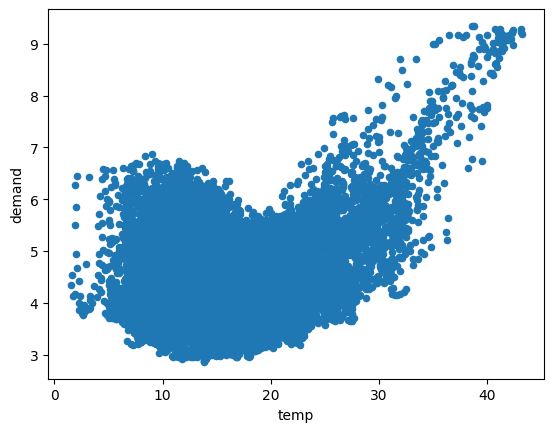

In [4]:
elec.plot(kind='scatter', x='temp', y='demand');

In [5]:
# For this exercise only, we'll limit our focus to only days in which it was at least 20 degrees Celsius (68 F)
elec = elec[elec["temp"] > 15]

print(elec.shape)
elec.head()

(9807, 3)


,demand,workday,temp
0,3.914647,0,18.2
1,3.672550,0,17.9
2,3.497539,0,17.6
3,3.339145,0,16.8
4,3.204313,0,16.3


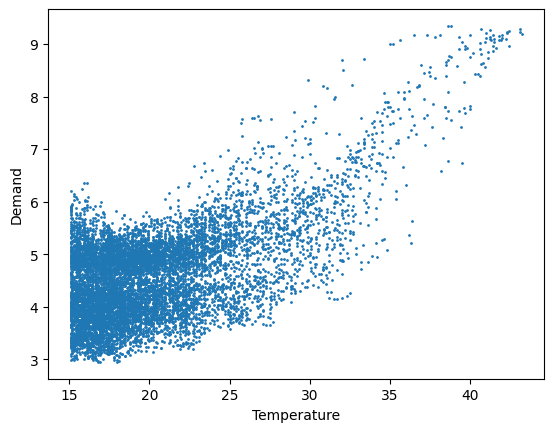

In [6]:
# Plot temperature vs. demand
plt.scatter(elec["temp"], elec["demand"], s=1)
plt.xlabel('Temperature')
plt.ylabel('Demand');

## The Null model

<details><summary>If we had to guess the demand for any new temperature what would you pick?</summary>
We don't have much information yet, so probably just the mean!
</details>

In [7]:
elec['demand'].mean()

4.624524730836953

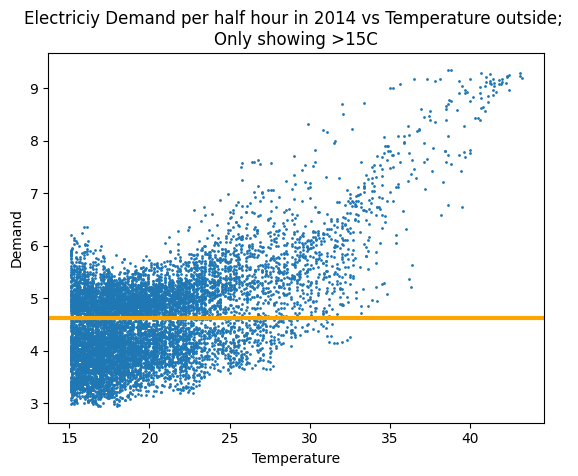

In [8]:
plt.scatter(elec["temp"], elec["demand"], s=1)
plt.axhline(elec['demand'].mean(), color = 'orange', lw=3)
plt.xlabel('Temperature')
plt.ylabel('Demand')
plt.title('Electriciy Demand per half hour in 2014 vs Temperature outside; \nOnly showing >15C');

## How could we improve our model?

<details><summary>If we were to draw a straight line that fit the points the best, what would that look like?</summary>
<img src="../images/ols.png", style="height: 350px">
</details>

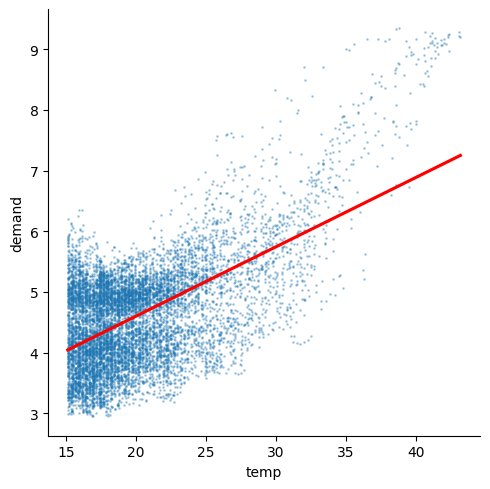

In [9]:
sns.lmplot(x='temp', y='demand', data=elec, ci=None, 
            scatter_kws = {'s': 1, 'alpha': 0.3}, 
            line_kws = {'color': 'red'});

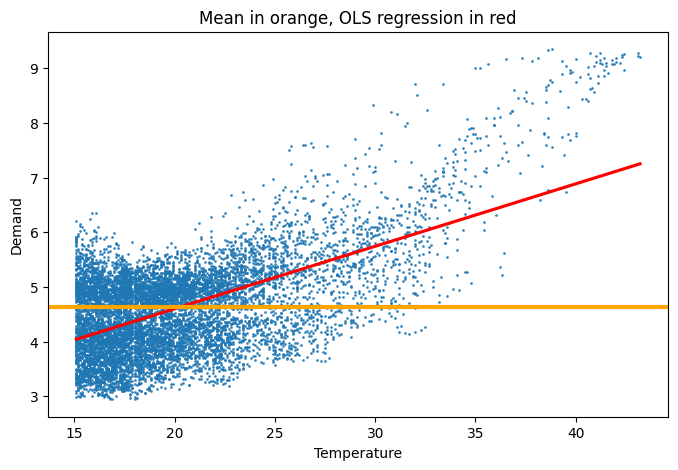

In [10]:
plt.figure(figsize = (8, 5))
sns.regplot(x='temp', y='demand', data=elec, ci=None, 
            scatter_kws = {'s': 1}, 
            line_kws = {'color': 'red'})
plt.axhline(elec['demand'].mean(), color = 'orange', lw=3)
plt.xlabel('Temperature')
plt.ylabel('Demand')
plt.title('Mean in orange, OLS regression in red');

**Is that line better fit the data than our old line that was just the mean?**

Looks like it. We'll discuss formal evaluation metrics in a bit.

## Lines

This was the equation I learned for a line. Look familiar?
$$ y = mx + b$$
In data science it gets changed to 

$$ y = \beta_0 + \beta_1 x_1 $$

### Errors

Our model isn't going to be perfect. The things our model doesn't capture are errors and denoted by $\epsilon$ (epsilon).

$$ y = \beta_0 + \beta_1 x_1 + \epsilon $$

### OLS Regression Modeling

We have _x_ and we have _y_. That's our data. 

Our model is trying to figure out the best betas. 

$$ \hat y = \hat \beta_0 + \hat \beta_1 x_1 $$


$\hat \beta_0$ is the y-intercept that our model learns. The point where the line crosses the y-axis.

$\hat \beta_1$ is the coefficient that we multiply by our $x_1$ variable. It's the slope. For every 1 unit it change in $x_1$, y increases by the value of $\beta1$.

$y$ is the ground truth of our target variable. 


$$ \hat y =  \hat\beta_0 +  \hat\beta_1 x_1 $$

When we have a model that has been fit with the data the betas have been computed. We can plug in a new x value and solve for $\hat y$. 

#### $\hat y$ is a prediction! 🎉

---
## OLS regression model in `scikit-learn`.

### Step 1: Assemble our predictor variables (X) and our target (y) 

 We need an X matrix that is n-by-p.
- n = rows
- p = features

A feature just means a predictor column.

In the simple linear regression case, p = 1. We have one feature ($x_1$). Usually you'll have more than 1 feature. 

In [11]:
# Step 1: Assemble our X and y variables

# We need an X matrix that is n-by-p (in this case, p = 1)
X = elec[["temp"]]

#### Why did we make X a `DataFrame`?
`scikit-learn` expects a two dimensional object. Usually we have more than one predictor variable.

y is the outcome variable

In [12]:
# We need a y vector that is length n
y = elec["demand"]

In [13]:
y.shape

(9807,)

#### Why is the target a `Series` or 1D numpy array? 

`scikit-learn` supervised learning estimators are expecting a single output column. They predict one value for each observation, generally.

### Step 2: Instantiate the model

In [14]:
# Step 2: Instantiate the model
lr = LinearRegression()

### Step 3: Fit the model

In [15]:
# Step 3: Fit the model
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.11]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['temp']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.319
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


### Step 4: Check out and interpret our model weights

In [16]:
# Take a peek at the model coefficient and intercept
print(lr.intercept_)
print(lr.coef_)

2.318762978267356
[0.11415682]


We now have the following model of reality:

$$\hat{d} = 2.32 + 0.11t$$

#### Interpretation of coefficients

In general, we can interpret our slope as having the following impact:
> For every 1 unit increase in $x_i$, we expect $y$ to increase by $\beta_i$.

<details><summary><font style = 'color:green'>How would we interpret the slope for our model?</font></summary>
For every 1 degree increase in temperature, we would expect 0.11 more gigawatts of electricty to be demanded. 
</details>

#### Interpretation of our y-intercept. Does it make sense?

When it is zero degrees Celsius, we expect 2.32 gigawatts of electricity to be demanded. Ordinarily, this _would_ make sense, however, we have no data near this value (remember, we removed lots for the purpose of this exercse) and would want to avoid **extrapolation**.

### Step 5: Make predictions

If we had new data points for temperature we could pass it to the `predict` method to generate price predictions.

We don't have any new data, so let's just see what predictions our model would have made. This is the same as saying "Find the x value for a prediction on the plot and go up to our line. That value for y is our prediction."

We do this for all the x values.

In [17]:
# Make predictions
y_pred = lr.predict(X)

In [18]:
np.set_printoptions(legacy='1.21') # this is to avoid scientific notation in the output

In [19]:
list(lr.predict(X))

[4.396417122629515,
 4.362170076293875,
 4.327923029958235,
 4.236597573063195,
 4.179519162503795,
 4.213766208839435,
 4.213766208839435,
 4.2251818909513155,
 4.168103480391915,
 4.213766208839435,
 4.350754394181996,
 4.385001440517636,
 4.499158261636435,
 4.636146446978994,
 4.590483718531475,
 4.750303268097795,
 4.818797360769075,
 4.921538499775995,
 4.990032592447275,
 5.058526685118554,
 5.127020777789834,
 5.172683506237355,
 5.286840327356154,
 5.264008963132395,
 5.206930552572995,
 5.206930552572995,
 5.0242796387829145,
 5.012863956671035,
 4.818797360769075,
 4.544820990083955,
 4.476326897412674,
 4.533405307972075,
 4.807381678657195,
 5.001448274559155,
 4.898707135552235,
 4.9101228176641145,
 4.784550314433435,
 4.967201228223514,
 4.830213042880954,
 4.864460089216594,
 4.830213042880954,
 4.841628724992836,
 4.853044407104715,
 4.841628724992836,
 4.784550314433435,
 4.647562129090875,
 4.5676523543077145,
 4.521989625860195,
 4.4534955331889154,
 4.396417122629

#### Why don't we pass `y`?

We are predicting y.

In [20]:
elec['demand'].mean()

4.624524730836953

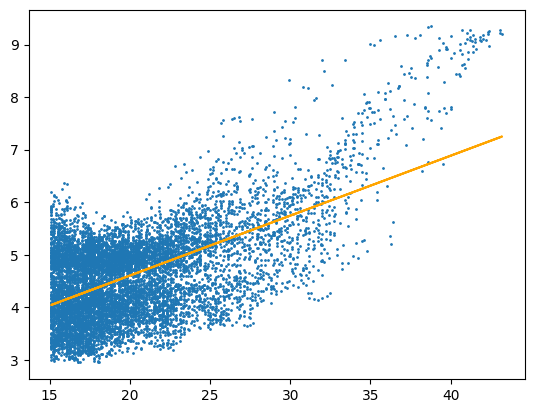

In [21]:
# We can plot them, too!
plt.scatter(elec["temp"], elec["demand"], s=1)
plt.plot(elec["temp"], y_pred, color='orange');

---

To the slides!

---

### Step 6: Evaluation

We now want to see how good a job our model does at predicting demand. **Mean squared error** is a popular scoring metric. 

Lower is better. That's the case whenever "error" is in the metric name.

$$ MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum e_i^2 $$

#### MSE by hand:

In [22]:
# Create residuals (aka errors): (y - y_hat)
resids = y - y_pred

In [23]:
# Compute the MSE
mse = np.mean(resids**2)
mse

0.5050316037069877

#### How does that model compare to our null model?

In [24]:
# Create the predictions for the "null model"
y_bar = np.mean(y)

In [25]:
# The null MSE
null_mse = np.mean((y - y_bar)**2)
null_mse

0.779688546631205

<details><summary>Which model fits the data better?</summary>
The OLS model has lower error.
</details>

Another popular regression metric is the $R^2$, which is defined as:

$$R^2 = 1 - \frac{\text{SSE}}{\text{Null SSE}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

The $R^2$, or **coefficient of determination**, is the proportion of variability in $y$ we can explain with $x$.

In [26]:
# The R2
1 - mse / null_mse

0.3522649449077143

#### Interpret $R^2$

35.2% of the variability in electricity demand can be explained by temperature.

We don't have to calculate these metrics by hand. `sklearn` can do it for us!

In [27]:
# MSE
metrics.mean_squared_error(y, y_pred)

0.5050316037069877

In [28]:
# RMSE
metrics.root_mean_squared_error(y, y_pred)

0.7106557561203509

In [29]:
# Can compute R2 from metrics...
metrics.r2_score(y, y_pred)

0.3522649449077143

In [30]:
# ... or directly from the model...
lr.score(X, y)

0.3522649449077143

### You made your first Linear Regression Model 🎉

---

To the slides!

---

## LINE Assumptions
Let's check em!

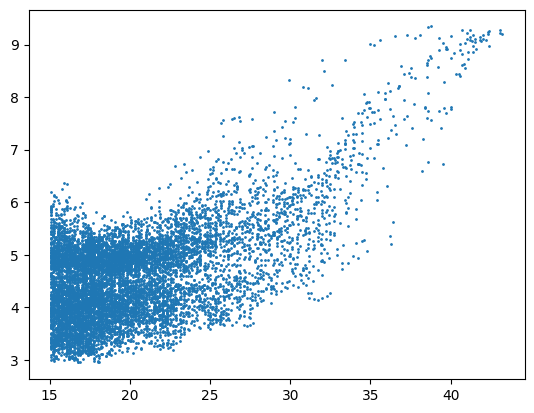

In [31]:
# L - Linearity
plt.scatter(elec["temp"], elec["demand"], s=1);

<details><summary>Does this pass our L assumption?</summary>
It's definitely a little curved, but this looks okay.
</details>

In [32]:
# I - Independence

<details><summary>Does this pass our I assumption?</summary>
Yes, by assumption.
</details>

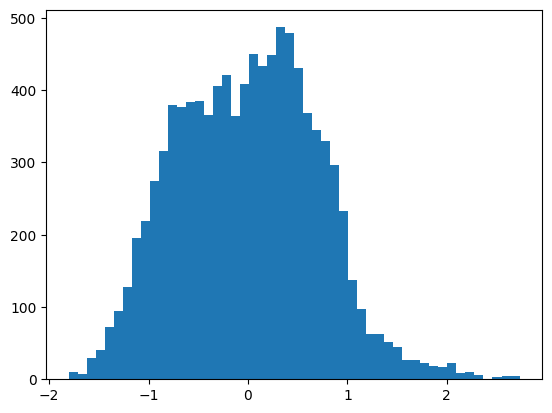

In [33]:
# N - Normality of errors
plt.hist(resids, bins=50);

<details><summary>Does this pass our N assumption?</summary>
Just like with the Linearity assumption, this isn't great, but we might be able to get away with it.
</details>

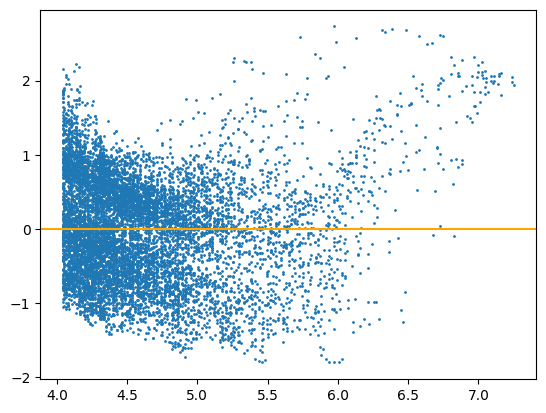

In [34]:
# E - Equal variance of errors
plt.scatter(y_pred, resids, s=1)
plt.axhline(0, color="orange");

<details><summary>Does this pass our E assumption?</summary>
I'm gonna go with no on this one...
</details>